# Calculating 3D EOFs from GODAS data
## Created by Dani Lafarga on 3/13/2026 
## Updated on 3/19/2026

Program outline:
- Section 0: Download GODAS data
  - This section downloads the GODAS data to a specified directory. If data is already dowloaded DO NOT RUN!
- Section 1: Read GODAS data
  - Will read in GODAS data for one month and save to a space time data matrix. This section also defines the data's associated time, latitude, longitude, and depth variables
- Section 2: Calculate climatology and anomalies
  - Calculated the time average (climatology) and the anomalies (data - climatology)
- Section 3: Calculate EOFs and PCs
  - Calculated EOF, PCs, and singular values using reduced SVD
- Section 4: Plot EOF and PC

In [ ]:
# to get path
import os

# libraries to read data
import netCDF4 as nc
from netCDF4 import Dataset as ds
import numpy as np

# libraries used for some math
from numpy import linspace
from numpy import meshgrid
import math

import urllib.request

from mpl_toolkits.basemap import Basemap
import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
# Creating the custom colorbar
top2 = cm.get_cmap('GnBu_r')   # get green blue colormap
bottom2 = cm.get_cmap('hot_r') # get hot colormap
top_array = top2(np.linspace(0, 1, 128))        # create array with colorvalues
bottom_array = bottom2(np.linspace(0, .9, 128)) # create array with colorvalues
# edit array with color values to have better transition shades
top_array[-2:,:] = bottom_array[0,:]
top_array[-3,:] = np.array([1., 0.98823529, 1., 1.])
top_array[-4,:] = np.array([0.96862745, 0.98823529, 1., 1.])
top_array[-5,:] = np.array([0.96862745, 0.98823529, 0.94117647, 1.])

newcolors2 = np.vstack((top_array, bottom_array))         # stacking color arrays on top of each other
newcmp2 = ListedColormap(newcolors2, name='OrangeBlue')   # creating new colormap

#################################################################################################################
# Function downloads GODAS data from url
# Input: 
#         - data_directory: string with the directory to save the data
#         - year: int with the year to download
# Output:
#         - downloads the data to file
def download_godas_file(data_directory, year):
  # Download the file from the URL
  url = 'https://downloads.psl.noaa.gov/Datasets/godas/pottmp.' + str(year) +'.nc'

  # Define a local filename to save the downloaded data
  local_filename = 'pottmp.' + str(year) + '.nc'
  local_filename = os.path.join(data_directory, local_filename)
    
  # Download the file from the URL
  print(f"Downloading {url} to {local_filename}...")
  urllib.request.urlretrieve(url, local_filename)
  print("Download complete.")
  return 

#################################################################################################################
#################################################################################################################
# Function reads GODAS temperature data for a specified year and month
# Input: 
#         - local_filename: name of file with godas data
#         - month: month to read in 
# Output:
#         - temp: 3D array (depth, lat, lon) with temperature values
def read_godas_file(local_filename, month):
  data = ds(local_filename, 'r')
  temp   = data.variables['pottmp'][month-1,:,:,:]  # read in temperature for one month
  temp.set_fill_value(np.nan)               # set fill value to NaN
  temp = temp.filled()                      # fill with NaN
  data.close()
  return temp
#################################################################################################################
#################################################################################################################
# Function reads GODAS data latitude, longitude, and depth variables
# Input: 
#         - local_filename: file to read the variables from
# Output:
#         - lat: 1d array with latitude values
#         - lon: 1d array with longitude values
#         - depths: 1d array with depth values

def get_var(local_filename):
  data = ds(local_filename, 'r')
  lat    = data.variables['lat'][:].data    # read in latitude
  lon    = data.variables['lon'][:].data    # read in longitude
  depths = data.variables['level'][:].data  # read in depth
  data.close()
  return lat, lon, depths

#################################################################################################################
#################################################################################################################
# Function computes volume weights based on latitude and depth values. Although longitude values are not
# in the equation the length of the longitude array is necessary for building 3D volume weight array 
# Input:
#         - lat: 1d array with all latitude values
#         - lon: 1d array with all longitude values
#         - depth: 1d array with all depth values
# Output: 
#         - volume_weight: 3D array with volume weights
# Important variables:
#         - xx: 2D array of longitude values from 1D array lon. It is size (lat, lon)
#         - yy: 2D array of latitude values from 1D array lat. It is size (lat, lon)
#         - tot_depth: integer of the total amount of depths specified by input depth
#         - area_w: 2D array with the cosine of radian latitude values this will later be multiplied by depth layer thickness 
def vol_weight(depths, lon, lat):
    xx, yy = meshgrid(lon, lat) # create a 2D array with longitude and latitude values for one depth
    tot_depth = len(depths)     # int of the total amount of depths
    
    # area weight for lattitude values
    area_w = np.cos(yy*math.pi/180) # change latitude degrees to radians
    if lat[-1] == 90.0:             # accounting for the 0 truncation at 90 degrees          
        area_w[-1,:] = 0.0
    # area weights for depth
    volume_weight = []
    for i in range(tot_depth): # for each depth
        if i == 0:             # first deoth thickness is surface(0) to the first depth
            volume_weight.append(np.sqrt(depths[0] * area_w)) # first depth thickness
        else:
            volume_weight.append( np.sqrt((depths[i] - depths[i - 1]) * area_w))
    # Turning weights into one array
    volume_weight = np.array(volume_weight)
    return volume_weight


# Section 0: Download data
Only run this if the GODAS data has not been downloaded


In [ ]:
data_directory = 'E:/GODAS'
for year in np.arange(1980, 2026):
    download_godas_file(data_directory, year)

# Section 1: Read GODAS data
Reads in data and saves in to **data_array**, a $N \times Y$ space time data matrix where:
-  N: total amount of gridpoints
-  Y: total time steps


In [419]:
# change file directory to read the data
os.chdir('E:\GODAS')

# reading in the variables for one file
local_filename = 'pottmp.1980.nc'            # call a GODAS file
lat, lon, depths = get_var(local_filename)   # read in variables
years = np.arange(1980,2026)                 # define years for data

# read in GODAS data
month = 1 # which month to read in 
data_array = np.zeros((len(lat)*len(lon)*len(depths), len(years))) # initialize space time data matrix

# read in data and put into space time data matrix
for i, year in enumerate(years):
    local_filename = 'pottmp.' + str(year) + '.nc'
    data_array[:,i] = read_godas_file(local_filename, month).flatten()

# Section 2: Calculate Clim and Anom

In [421]:
import warnings

# I expect to see RuntimeWarnings in this block

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    clim = np.nanmean(data_array, axis = 1)   # climatology  

# calculate anomalies
anom = data_array - clim[:, np.newaxis] 
del data_array # just to clean up space

# Calculate EOFs
SVD is used to calculate the EOFs, PCs, and singular values from the anomaly matrix $A_{N \times Y}$. Since NaNs cannot be present for SVD they are taken out which produces a new anomaly matrix $A_{N' \times Y}$. 

\begin{equation}
A_{N' \times Y} = U_{N' \times Y}D_{Y \times Y}Vt_{Y \times Y}
\end{equation}
Where:
- U: EOF matrix with EOFs in the columns
- D: Diagonal matrix with singular values in diagonal
- Vt: PC matrix with PCs in the columns
- N': total grid points with values
- Y: total amount of timesteps

In [426]:
# add volume weights to anomalies
volume_weights = vol_weight(depths, lon, lat) # Calculate volume weights
wgts = volume_weights.flatten()               # flatten to same spatial dimensions 
anom = anom * wgts[:, np.newaxis]             # multiply volume weights to anomalies

# Find valid (non-NaN) spatial points to remove NaN
valid = ~np.isnan(anom).any(axis=1)   # (space,) boolean mask
anom_clean = anom[valid, :]           # (valid_space, time)

In [428]:
# Calculate SVD
# U: the EOF space time matrix with EOFs in columns
# s: the singular values
# Vt: matrix with PCs in the columns
U, s, Vt = np.linalg.svd(anom_clean, full_matrices=False)

# Plot EOFs and PCs

In [114]:
# Put EOFs back into full spatial grid (NaNs where missing)
n_modes = 5 # specify how many modes you want to keep
EOFs_full = np.full((anom.shape[0], n_modes), np.nan) # initialize EOF matix with NaN
EOFs_full[valid, :] = U[:, :n_modes]                  # put EOF values into appropriate spots
EOFs_full = EOFs_full.reshape(len(depths), len(lat), len(lon), n_modes) # reshape so it is 4D array

EOFs_full = EOFs_full / volume_weights[..., np.newaxis] # divide out spatial weights for plotting

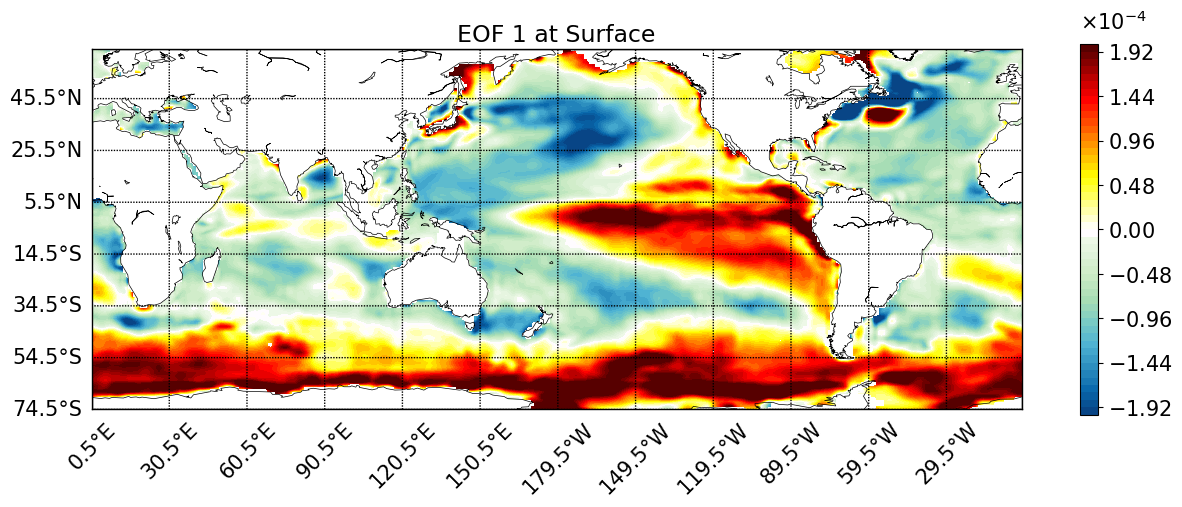

In [447]:
# define depth and mode to plot
depth_ind = 0
mode = 1

# define the size of labels
exp_sz = 12
label_sz = 15
title_sz = 17

# create figure object
fig = plt.figure(figsize=(15, 13))
ax = fig.add_subplot(111)

# adding map
mymap = Basemap(projection='cyl', llcrnrlat=lat[0], urcrnrlat=lat[-1],
                llcrnrlon=lon[0], urcrnrlon=lon[-1], resolution='c')
mymap.drawcoastlines(color='black', linewidth=.5)
mymap.drawmapboundary()
mymap.drawparallels(np.arange(lat[0], lat[-1], 20), labels=[1, 0, 0, 0], fontsize=label_sz)
mymap.drawmeridians(np.arange(lon[0], lon[-1], 30), labels=[0, 0, 0, 1], fontsize=label_sz, rotation = 45)

# setting up colormap for colorbar
clip = .0002    # define colorbar limits
levels = 50     # set how many colors you want to plot
levels = np.linspace(-clip, clip, levels + 1) # sets ticks on colorbar
norm = mpl.colors.Normalize(vmin=-clip, vmax=clip)

# plot contour on map
cs = plt.contourf(
    lon, lat, np.clip(-EOFs_full[0, :, :, mode-1], -clip, clip),
    levels = levels,
    cmap=newcmp2,
    norm=norm,
)


# Title
if depth_ind == 0:
    plt.title(f"EOF {mode} at Surface", size=title_sz)
else:
    plt.title(f"EOF {mode} at {round(depths[depth_ind])} m", size=title_sz)

# the colorbar for the data
cbar = plt.colorbar(cs, format = mpl.ticker.ScalarFormatter(useMathText=True), shrink = .37)
cbar.ax.yaxis.get_offset_text().set_fontsize(label_sz) # change exp size
cbar.ax.yaxis.OFFSETTEXTPAD = 11           # moving exponent so it doesnt overlap with top of colorbar
cbar.ax.yaxis.set_offset_position('left')  # setexponent so it is more left 
cbar.ax.tick_params(labelsize=label_sz)    # set label size of ticks
cbar.formatter.set_powerlimits((0, 0))     # formatting scientific notation
cbar.update_ticks()



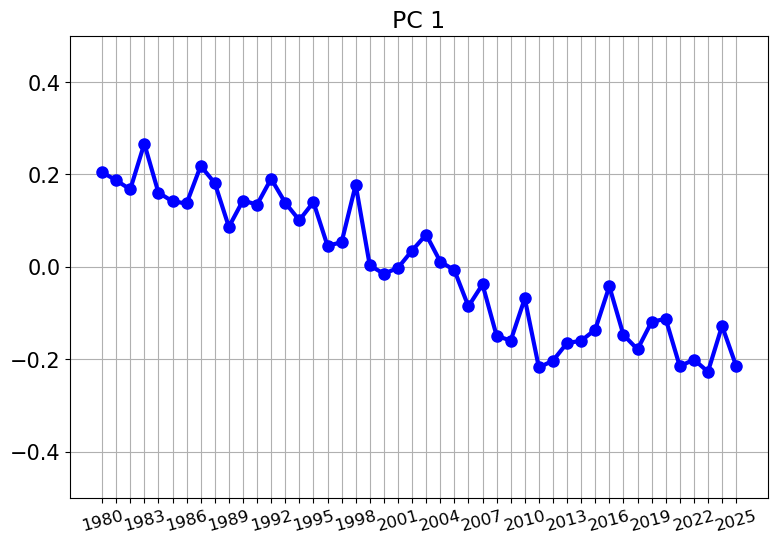

In [368]:
# plot time series
mode = 1

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111)

line = 3
clip = .5
plt.plot(years, -Vt[mode-1, :],'b', marker = 'o',label = 'PC with Cov', linewidth=line, markersize = line+5)

# formatting ticks and axes labels
plt.xticks(years)
plt.xticks(rotation=15)
plt.xticks(fontsize = 17)
plt.ylim([-clip,clip])
plt.yticks(fontsize = 17)
plt.title('PC ' + str(mode), fontsize=title_sz)
ax.set_xticklabels([])
ax.tick_params(axis='y', labelsize=label_sz)  # You can set any size you want
plt.grid(True)

# Get the current ticks
xticks = ax.get_xticks()

# Set labels for every third tick, leave others blank
xtick_labels = [str(int(tick)) if i % 3 == 0 else '' for i, tick in enumerate(xticks)]
ax.set_xticklabels(xtick_labels)
ax.tick_params(axis='x', labelsize=label_sz-3)  # You can set any size you want
